# Exploración SESCO — Producción de petróleo y gas (Argentina)

Notebook exploratoria para el MVP **Oil & Gas Dashboard**.

- Fuente CKAN: [energia-produccion-petroleo-gas-sesco](https://datos.gob.ar/dataset/energia-produccion-petroleo-gas-sesco)
- Objetivo: entender recursos, columnas y calidad de datos antes de API/DB/dashboard.
- `backend/` y `frontend/` quedan pausados durante esta etapa.

## 1. Importar librerías

In [1]:
import re
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import requests

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

# Rutas relativas al directorio exploration/
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == "notebooks":
    EXPLORATION_DIR = NOTEBOOK_DIR.parent
else:
    EXPLORATION_DIR = NOTEBOOK_DIR / "exploration"

RAW_DIR = EXPLORATION_DIR / "data" / "raw"
PROCESSED_DIR = EXPLORATION_DIR / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Exploration dir: {EXPLORATION_DIR}")

Exploration dir: c:\Proyectos\Dashboards\OilAndGas\exploration


## 2. Consultar API CKAN

In [2]:
PACKAGE_ID = "energia-produccion-petroleo-gas-sesco"
CKAN_URL = f"https://datos.gob.ar/api/3/action/package_show?id={PACKAGE_ID}"
HEADERS = {"User-Agent": "OilGas-Exploration/1.0"}

response = requests.get(CKAN_URL, headers=HEADERS, timeout=60)
response.raise_for_status()
payload = response.json()

print(f"HTTP status: {response.status_code}")
print(f"success: {payload.get('success')}")

HTTP status: 200
success: True


## 3. Validar respuesta

In [3]:
assert payload.get("success") is True, "CKAN no devolvió success=True"
assert "result" in payload, "Falta clave 'result' en la respuesta"

package = payload["result"]
resources = package.get("resources", [])

print(f"Dataset: {package.get('title')}")
print(f"Recursos: {len(resources)}")
print(f"Última modificación del paquete: {package.get('metadata_modified')}")

Dataset: Producción de Petróleo y Gas (SESCO)
Recursos: 41
Última modificación del paquete: 2026-06-18T16:11:34.343905


## 4–6. DataFrame de recursos y listado ordenado

In [11]:
df_aux = pd.DataFrame([{i: resource.get(i) for i, _ in resource.items()} for resource in resources])
df_aux.head()

,accessURL,cache_url,mimetype_inner,hash,description,format,url,created,state,cache_last_updated,package_id,last_modified,mimetype,url_type,position,revision_id,size,id,resource_type,name,fileName,attributesDescription
0,http://datos.energia.gob.ar/dataset/590d1284-f...,None,None,,Tablas Dinámicas SESCO.\r\nACLARACIÓN: El camp...,ZIP,http://www.energia.gob.ar/contenidos/archivos/...,2016-12-22T10:47:52.898661,active,None,energia_590d1284-fd6d-4686-afd8-b3da5d90a6e9,2023-11-24T17:11:31.273629,None,None,0,7f926dbc-aa18-4203-9d01-9393140d6b65,None,energia_3752bb79-7229-4a3b-8f61-c617bfb17677,NaN,Producción de Petróleo y Gas - desde 2019 - Se...,NaN,NaN
1,http://datos.energia.gob.ar/dataset/590d1284-f...,None,None,,,ZIP,http://www.energia.gob.ar/contenidos/archivos/...,2016-12-22T10:49:34.979944,active,None,energia_590d1284-fd6d-4686-afd8-b3da5d90a6e9,2019-03-07T15:19:37.091230,None,None,1,af307a5d-c03c-4686-b367-7b880261f857,None,energia_34415dd6-2dd6-4480-a464-62dcdcf6241b,NaN,Balances de Gas - desde 2009 - Sesco Web (Tabl...,NaN,NaN
2,http://datos.energia.gob.ar/dataset/590d1284-f...,None,None,,,ZIP,http://www.energia.gob.ar/contenidos/archivos/...,2023-11-24T17:03:36.936971,active,None,energia_590d1284-fd6d-4686-afd8-b3da5d90a6e9,2023-11-24T17:03:36.936971,None,None,2,af307a5d-c03c-4686-b367-7b880261f857,None,energia_5f5b0299-9407-4399-90b4-332b10c914cf,NaN,Producción de Petróleo y Gas - 2009 a 2018 - (...,NaN,NaN
3,http://datos.energia.gob.ar/dataset/590d1284-f...,None,None,,,ZIP,http://www.energia.gob.ar/contenidos/archivos/...,2016-12-22T10:48:52.046439,active,None,energia_590d1284-fd6d-4686-afd8-b3da5d90a6e9,NaN,None,None,3,af307a5d-c03c-4686-b367-7b880261f857,None,energia_f4cf0c95-68c7-476e-b279-89e0d43b1b71,NaN,Producción de Petróleo y Gas - hasta 2008 - (...,NaN,NaN
4,http://datos.energia.gob.ar/dataset/590d1284-f...,None,None,,,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:44:36.427932,active,None,energia_590d1284-fd6d-4686-afd8-b3da5d90a6e9,2017-07-28T09:44:37.454531,None,None,4,7f926dbc-aa18-4203-9d01-9393140d6b65,None,energia_99386094-7986-42db-8a9b-a55e37c0553e,NaN,Disponibilidad de petróleo a fin de mes ant. 2009,disponibilidad-de-petrleo-a-fin-de-mes-ant-200...,NaN


In [12]:
resource_fields = ["name", "id", "format", "url", "created", "last_modified", "size"]

df_resources = pd.DataFrame(
    [{field: resource.get(field) for field in resource_fields} for resource in resources]
)

df_resources = df_resources.sort_values("name", key=lambda s: s.str.lower()).reset_index(drop=True)
df_resources.head()

,name,id,format,url,created,last_modified,size
0,Balance de gas desde 2009,energia_11614a62-9713-4b8f-8b8c-2a8050780140,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2018-12-17T20:11:17.705871,2026-06-16T05:00:37.760208,None
1,Balances de Gas - desde 2009 - Sesco Web (Tabl...,energia_34415dd6-2dd6-4480-a464-62dcdcf6241b,ZIP,http://www.energia.gob.ar/contenidos/archivos/...,2016-12-22T10:49:34.979944,2019-03-07T15:19:37.091230,None
2,Disponibilidad de petróleo a fin de mes ant. 2009,energia_99386094-7986-42db-8a9b-a55e37c0553e,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:44:36.427932,2017-07-28T09:44:37.454531,None
3,Dist. de condensado y existencias a fin de mes...,energia_9cd9a075-5a6b-4e0a-9f7a-11511601deb3,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:44:50.899381,2017-07-28T09:44:52.176571,None
4,Distribucion de gasolina y existencias a fin d...,energia_9bcc12ab-4a6e-477e-9e86-0a384cc5bb6a,CSV,http://datos.energia.gob.ar/dataset/590d1284-f...,2017-07-28T08:45:06.563685,2017-07-28T09:45:10.519549,None


## 7. Recursos candidatos por palabras clave

In [15]:
KEYWORDS = [
    "petroleo", "petróleo", "gas", "provincia", "cuenca",
    "empresa", "sesco", "shale", "tight",
]


def normalize_text(value: str) -> str:
    """Minúsculas sin acentos para búsqueda flexible."""
    if not isinstance(value, str):
        return ""
    text = unicodedata.normalize("NFKD", value)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    return text.lower()


def match_keywords(name: str, keywords: list[str]) -> list[str]:
    normalized = normalize_text(name)
    return [kw for kw in keywords if normalize_text(kw) in normalized]


df_candidates = df_resources.copy()
df_candidates["keywords_matched"] = df_candidates["name"].apply(
    lambda name: match_keywords(name, KEYWORDS)
)
df_candidates = df_candidates[df_candidates["keywords_matched"].map(len) > 0]
df_candidates[["name", "format", "keywords_matched", "url"]]

,name,format,keywords_matched,url
0,Balance de gas desde 2009,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
1,Balances de Gas - desde 2009 - Sesco Web (Tabl...,ZIP,"[gas, sesco]",http://www.energia.gob.ar/contenidos/archivos/...
2,Disponibilidad de petróleo a fin de mes ant. 2009,CSV,"[petroleo, petróleo]",http://datos.energia.gob.ar/dataset/590d1284-f...
4,Distribucion de gasolina y existencias a fin d...,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
5,Distribución de petróleo y existencias a fin d...,CSV,"[petroleo, petróleo]",http://datos.energia.gob.ar/dataset/590d1284-f...
6,Gas entregado por plantas,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
7,Gas recibido retenido aventado por plantas,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
8,"Gas retenido, recibido y aventado ant. 2009",CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
9,Producción de gas anterior al 2009,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...
10,Producción de gas por area y conformación de c...,CSV,[gas],http://datos.energia.gob.ar/dataset/590d1284-f...


## 8. Identificar recursos iniciales para el MVP

In [16]:
MVP_TARGETS = {
    "petroleo_provincia": ["petroleo", "provincia"],
    "gas_provincia": ["gas", "provincia"],
    "petroleo_cuenca": ["petroleo", "cuenca"],
    "gas_cuenca": ["gas", "cuenca"],
    "petroleo_empresa": ["petroleo", "empresa"],
    "gas_empresa": ["gas", "empresa"],
}


def find_mvp_resource(target_keywords: list[str]) -> pd.Series | None:
    """Busca el recurso CSV más reciente que contenga todas las palabras clave."""
    matches = []
    for _, row in df_resources.iterrows():
        normalized = normalize_text(row["name"])
        if all(normalize_text(kw) in normalized for kw in target_keywords):
            matches.append(row)
    if not matches:
        return None

    df_match = pd.DataFrame(matches)
    # Preferir CSV y recursos de producción promedio diaria
    df_match["is_csv"] = df_match["format"].str.upper().eq("CSV")
    df_match["is_promedio"] = df_match["name"].apply(
        lambda x: "promedio" in normalize_text(x)
    )
    df_match = df_match.sort_values(
        ["is_csv", "is_promedio", "last_modified"],
        ascending=[False, False, False],
    )
    return df_match.iloc[0]


mvp_resources = {}
for label, keywords in MVP_TARGETS.items():
    match = find_mvp_resource(keywords)
    mvp_resources[label] = match
    status = "OK" if match is not None else "NO ENCONTRADO"
    name = match["name"] if match is not None else "—"
    print(f"[{status}] {label}: {name}")

df_mvp = pd.DataFrame(
    {
        "mvp_target": list(mvp_resources.keys()),
        "found": [v is not None for v in mvp_resources.values()],
        "name": [v["name"] if v is not None else None for v in mvp_resources.values()],
        "url": [v["url"] if v is not None else None for v in mvp_resources.values()],
    }
)
df_mvp

[OK] petroleo_provincia: Producción de petróleo promedio diaria por provincia
[OK] gas_provincia: Producción de gas promedio diaria por provincia
[OK] petroleo_cuenca: Producción de petróleo promedio diaria por cuenca
[OK] gas_cuenca: Producción de gas promedio diaria por cuenca
[OK] petroleo_empresa: Producción de petróleo promedio diaria por empresa
[OK] gas_empresa: Producción de gas promedio diaria por empresa


,mvp_target,found,name,url
0,petroleo_provincia,True,Producción de petróleo promedio diaria por pro...,http://datos.energia.gob.ar/dataset/590d1284-f...
1,gas_provincia,True,Producción de gas promedio diaria por provincia,http://datos.energia.gob.ar/dataset/590d1284-f...
2,petroleo_cuenca,True,Producción de petróleo promedio diaria por cuenca,http://datos.energia.gob.ar/dataset/590d1284-f...
3,gas_cuenca,True,Producción de gas promedio diaria por cuenca,http://datos.energia.gob.ar/dataset/590d1284-f...
4,petroleo_empresa,True,Producción de petróleo promedio diaria por emp...,http://datos.energia.gob.ar/dataset/590d1284-f...
5,gas_empresa,True,Producción de gas promedio diaria por empresa,http://datos.energia.gob.ar/dataset/590d1284-f...


## 9. Descargar un CSV candidato

In [34]:
# Recurso principal para esta exploración: petróleo promedio diario por provincia
selected_resource = mvp_resources.get("petroleo_provincia")
if selected_resource is None:
    selected_resource = df_resources[
        df_resources["format"].str.upper().eq("CSV")
    ].iloc[0]

print(f"Recurso seleccionado:\n {selected_resource}")
download_url = selected_resource["url"]
source_resource_name = selected_resource["name"]
local_filename = "produccion_petroleo_promedio_diaria_por_provincia.csv"
local_path = RAW_DIR / local_filename

print(f"Recurso: {source_resource_name}")
print(f"URL: {download_url}")

if not local_path.exists():
    file_response = requests.get(download_url, headers=HEADERS, timeout=120)
    file_response.raise_for_status()
    local_path.write_bytes(file_response.content)
    print(f"Descargado en: {local_path}")
else:
    print(f"Ya existe: {local_path}")

Recurso seleccionado:
 name             Producción de petróleo promedio diaria por pro...
id                    energia_a512fef1-e98e-44af-b940-76168a4bc523
format                                                         CSV
url              http://datos.energia.gob.ar/dataset/590d1284-f...
created                                 2019-05-31T14:10:54.844017
last_modified                           2026-02-11T13:41:52.196181
size                                                           NaN
is_csv                                                        True
is_promedio                                                   True
Name: 23, dtype: object
Recurso: Producción de petróleo promedio diaria por provincia
URL: http://datos.energia.gob.ar/dataset/590d1284-fd6d-4686-afd8-b3da5d90a6e9/resource/a512fef1-e98e-44af-b940-76168a4bc523/download/produccin-de-petrleo-promedio-diaria-por-provincia.csv
Ya existe: c:\Proyectos\Dashboards\OilAndGas\exploration\data\raw\produccion_petroleo_promedio_diari

## 10–11. Leer CSV e inspeccionar estructura

In [35]:
df_raw = pd.read_csv(local_path, encoding="utf-8-sig")
print(f"Filas: {len(df_raw):,} | Columnas: {len(df_raw.columns)}")
df_raw.head(10)

Filas: 2,505 | Columnas: 5


,anio,mes,indice_tiempo,provincia,produccion_petroleo_promedio_dia_m3
0,2009,1,2009-01,Chubut,25615.042484
1,2009,1,2009-01,Estado Nacional,684.083226
2,2009,1,2009-01,Formosa,416.606452
3,2009,1,2009-01,Jujuy,46.487742
4,2009,1,2009-01,La Pampa,3925.047097
5,2009,1,2009-01,La Rioja,0.000000
6,2009,1,2009-01,Mendoza,15649.815935
7,2009,1,2009-01,Neuquén,22097.323870
8,2009,1,2009-01,Rio Negro,5885.357194
9,2009,1,2009-01,Salta,1662.384516


In [36]:
print("Columnas:", list(df_raw.columns))
print("\nTipos de datos:")
print(df_raw.dtypes)

print("\nValores nulos:")
print(df_raw.isna().sum())

print("\nCardinalidad por columna:")
for col in df_raw.columns:
    print(f"  {col}: {df_raw[col].nunique()} únicos")

Columnas: ['anio', 'mes', 'indice_tiempo', 'provincia', 'produccion_petroleo_promedio_dia_m3']

Tipos de datos:
anio                                     int64
mes                                      int64
indice_tiempo                              str
provincia                                  str
produccion_petroleo_promedio_dia_m3    float64
dtype: object

Valores nulos:
anio                                   0
mes                                    0
indice_tiempo                          0
provincia                              0
produccion_petroleo_promedio_dia_m3    0
dtype: int64

Cardinalidad por columna:
  anio: 18 únicos
  mes: 12 únicos
  indice_tiempo: 205 únicos
  provincia: 15 únicos
  produccion_petroleo_promedio_dia_m3: 2240 únicos


In [37]:
# Rango temporal si existen columnas de fecha/período/año/mes
date_candidates = [c for c in df_raw.columns if any(
    token in normalize_text(c) for token in ["anio", "ano", "mes", "fecha", "periodo", "indice", "tiempo"]
)]
print("Columnas temporales detectadas:", date_candidates)

if "indice_tiempo" in df_raw.columns:
    print(f"Rango indice_tiempo: {df_raw['indice_tiempo'].min()} → {df_raw['indice_tiempo'].max()}")
if "anio" in df_raw.columns:
    print(f"Rango anio: {df_raw['anio'].min()} → {df_raw['anio'].max()}")
if "mes" in df_raw.columns:
    print(f"Rango mes: {df_raw['mes'].min()} → {df_raw['mes'].max()}")

Columnas temporales detectadas: ['anio', 'mes', 'indice_tiempo']
Rango indice_tiempo: 2009-01 → 2026-01
Rango anio: 2009 → 2026
Rango mes: 1 → 12


## 12. Funciones auxiliares de inspección

In [38]:
def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza nombres de columnas a snake_case sin acentos."""
    def clean(name: str) -> str:
        # Normalization Form Compatibility Decomposition (NFKD)
        # Es un algoritmo estándar de Unicode que estandariza cadenas de texto descomponiendo caracteres complejos en sus elementos más simples
        text = unicodedata.normalize("NFKD", str(name))

        text = "".join(ch for ch in text if not unicodedata.combining(ch))
        text = text.strip().lower()
        text = re.sub(r"[^a-z0-9]+", "_", text)
        return text.strip("_")

    out = df.copy()
    out.columns = [clean(col) for col in out.columns]
    return out


def detect_date_columns(df: pd.DataFrame) -> list[str]:
    tokens = ("anio", "ano", "mes", "fecha", "periodo", "indice", "tiempo")
    return [col for col in df.columns if any(token in col for token in tokens)]


def detect_numeric_columns(df: pd.DataFrame) -> list[str]:
    return df.select_dtypes(include="number").columns.tolist()


def detect_categorical_columns(df: pd.DataFrame) -> list[str]:
    numeric = set(detect_numeric_columns(df))
    date_like = set(detect_date_columns(df))
    return [col for col in df.columns if col not in numeric and col not in date_like]


def summarize_dataframe(df: pd.DataFrame) -> dict:
    return {
        "rows": len(df),
        "columns": len(df.columns),
        "date_columns": detect_date_columns(df),
        "numeric_columns": detect_numeric_columns(df),
        "categorical_columns": detect_categorical_columns(df),
        "null_counts": df.isna().sum().to_dict(),
    }


df_norm = normalize_column_names(df_raw)
summary = summarize_dataframe(df_norm)
summary

{'rows': 2505,
 'columns': 5,
 'date_columns': ['anio', 'mes', 'indice_tiempo'],
 'numeric_columns': ['anio', 'mes', 'produccion_petroleo_promedio_dia_m3'],
 'categorical_columns': ['provincia'],
 'null_counts': {'anio': 0,
  'mes': 0,
  'indice_tiempo': 0,
  'provincia': 0,
  'produccion_petroleo_promedio_dia_m3': 0}}

## 13. Normalización tentativa hacia modelo analítico

Construye `df_model` con el esquema común del MVP. La limpieza definitiva (fechas, período incompleto, nulos) se aplica en la **sección 14**.

In [39]:
TARGET_SCHEMA = [
    "periodo",
    "anio",
    "mes",
    "producto",
    "agrupador_tipo",
    "agrupador_nombre",
    "tipo_recurso",
    "produccion",
    "source_resource",
]


def infer_product(name: str) -> str:
    n = normalize_text(name)
    if "petroleo" in n or "petr" in n:
        return "petroleo"
    if "gas" in n:
        return "gas"
    return "desconocido"


def infer_group_type(name: str) -> str:
    n = normalize_text(name)
    for label in ("provincia", "cuenca", "empresa", "yacimiento", "pais"):
        if label in n:
            return label
    return "otro"


def infer_tipo_recurso(name: str) -> str | None:
    n = normalize_text(name)
    if "shale" in n or "tight" in n:
        return "shale_tight"
    if "promedio" in n:
        return "promedio_diario"
    if "historica" in n or "serie" in n:
        return "serie_historica"
    return None


def find_production_column(columns: list[str]) -> str | None:
    for col in columns:
        if "produccion" in col or col.startswith("prod"):
            return col
    numeric = detect_numeric_columns(df_norm)
    excluded = {"anio", "mes"}
    candidates = [c for c in numeric if c not in excluded]
    return candidates[0] if candidates else None


def find_group_column(columns: list[str], group_type: str) -> str | None:
    for col in columns:
        if group_type in col:
            return col
    cat_cols = detect_categorical_columns(df_norm)
    return cat_cols[0] if cat_cols else None


producto = infer_product(source_resource_name)
agrupador_tipo = infer_group_type(source_resource_name)
tipo_recurso = infer_tipo_recurso(source_resource_name)
prod_col = find_production_column(list(df_norm.columns))
group_col = find_group_column(list(df_norm.columns), agrupador_tipo)

df_model = pd.DataFrame()
df_model["periodo"] = df_norm["indice_tiempo"] if "indice_tiempo" in df_norm.columns else None
df_model["anio"] = df_norm["anio"] if "anio" in df_norm.columns else None
df_model["mes"] = df_norm["mes"] if "mes" in df_norm.columns else None
df_model["producto"] = producto
df_model["agrupador_tipo"] = agrupador_tipo
df_model["agrupador_nombre"] = df_norm[group_col] if group_col else None
df_model["tipo_recurso"] = tipo_recurso
df_model["produccion"] = df_norm[prod_col] if prod_col else None
df_model["source_resource"] = source_resource_name

print("Mapeo tentativo:")
print(f"  producto={producto}, agrupador_tipo={agrupador_tipo}, tipo_recurso={tipo_recurso}")
print(f"  produccion ← {prod_col}, agrupador_nombre ← {group_col}")
df_model.head(10)

Mapeo tentativo:
  producto=petroleo, agrupador_tipo=provincia, tipo_recurso=promedio_diario
  produccion ← produccion_petroleo_promedio_dia_m3, agrupador_nombre ← provincia


,periodo,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource
0,2009-01,2009,1,petroleo,provincia,Chubut,promedio_diario,25615.042484,Producción de petróleo promedio diaria por pro...
1,2009-01,2009,1,petroleo,provincia,Estado Nacional,promedio_diario,684.083226,Producción de petróleo promedio diaria por pro...
2,2009-01,2009,1,petroleo,provincia,Formosa,promedio_diario,416.606452,Producción de petróleo promedio diaria por pro...
3,2009-01,2009,1,petroleo,provincia,Jujuy,promedio_diario,46.487742,Producción de petróleo promedio diaria por pro...
4,2009-01,2009,1,petroleo,provincia,La Pampa,promedio_diario,3925.047097,Producción de petróleo promedio diaria por pro...
5,2009-01,2009,1,petroleo,provincia,La Rioja,promedio_diario,0.000000,Producción de petróleo promedio diaria por pro...
6,2009-01,2009,1,petroleo,provincia,Mendoza,promedio_diario,15649.815935,Producción de petróleo promedio diaria por pro...
7,2009-01,2009,1,petroleo,provincia,Neuquén,promedio_diario,22097.323870,Producción de petróleo promedio diaria por pro...
8,2009-01,2009,1,petroleo,provincia,Rio Negro,promedio_diario,5885.357194,Producción de petróleo promedio diaria por pro...
9,2009-01,2009,1,petroleo,provincia,Salta,promedio_diario,1662.384516,Producción de petróleo promedio diaria por pro...


## 14. Normalización y preprocesamiento

Pipeline reutilizable: aplicar una vez sobre `df_model` y usar `df_model_clean_valid` en todas las gráficas.

In [40]:
# Clave del recurso MVP (reutilizable para gas_provincia, petroleo_cuenca, etc.)
RESOURCE_KEY = "petroleo_provincia"

REQUIRED_COLUMNS = [
    "periodo",
    "produccion",
    "agrupador_nombre",
    "producto",
    "agrupador_tipo",
]


def preprocess_model_df(df_model: pd.DataFrame) -> pd.DataFrame:
    """Normaliza periodo, producción y filas mínimas para análisis."""
    df = df_model.copy()

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    df["periodo_original"] = df["periodo"]

    # periodo_str en formato YYYY-MM
    periodo_raw = df["periodo"].astype(str).str.strip()
    valid_mask = periodo_raw.str.match(r"^\d{4}-\d{1,2}$", na=False)
    periodo_str = periodo_raw.where(valid_mask)

    if "anio" in df.columns and "mes" in df.columns:
        anio_num = pd.to_numeric(df["anio"], errors="coerce")
        mes_num = pd.to_numeric(df["mes"], errors="coerce")
        fallback = (
            anio_num.astype("Int64").astype(str)
            + "-"
            + mes_num.astype("Int64").astype(str).str.zfill(2)
        )
        periodo_str = periodo_str.fillna(fallback)

    df["periodo_str"] = periodo_str
    df["periodo_dt"] = pd.to_datetime(
        df["periodo_str"] + "-01", format="%Y-%m-%d", errors="coerce"
    )
    df["periodo_dt"] = df["periodo_dt"].fillna(
        pd.to_datetime(df["periodo_str"], format="%Y-%m", errors="coerce")
    )
    df["anio"] = df["periodo_dt"].dt.year
    df["mes"] = df["periodo_dt"].dt.month

    df["produccion"] = pd.to_numeric(df["produccion"], errors="coerce")

    df = df.dropna(subset=["periodo_dt", "produccion", "agrupador_nombre"])
    df = df.sort_values(["periodo_dt", "agrupador_nombre"]).reset_index(drop=True)

    return df


def detectar_periodo_incompleto(df_model_clean: pd.DataFrame, threshold: float = 0.5) -> dict:
    """Marca el último período si su producción total es muy baja vs. el anterior."""
    agg = (
        df_model_clean.groupby(["periodo_dt", "periodo_str"], as_index=False)["produccion"]
        .sum()
        .sort_values("periodo_dt")
    )

    latest_period = agg.iloc[-1]["periodo_str"]
    latest_valid_period = latest_period
    excluded_period = None
    ratio = None
    periodos_validos = agg["periodo_dt"].tolist()

    if len(agg) >= 2:
        ultimo_valor = agg.iloc[-1]["produccion"]
        penultimo_valor = agg.iloc[-2]["produccion"]
        ratio = ultimo_valor / penultimo_valor if penultimo_valor else 1.0

        if ratio < threshold:
            excluded_period = latest_period
            latest_valid_period = agg.iloc[-2]["periodo_str"]
            periodos_validos = agg.iloc[:-1]["periodo_dt"].tolist()
            print(
                f"Advertencia: se excluye {excluded_period} porque parece incompleto. "
                f"Representa {ratio * 100:.1f}% del período anterior."
            )

    return {
        "latest_period": latest_period,
        "latest_valid_period": latest_valid_period,
        "excluded_period": excluded_period,
        "ratio": ratio,
        "periodos_validos": periodos_validos,
    }


def format_number(value, decimals=0):
    """Formato numérico local: coma decimal, sin separador de miles."""
    return f"{value:.{decimals}f}".replace(".", ",")


# --- Pipeline único de preprocesamiento ---
ROWS_ORIGINAL = len(df_model)

df_model_clean = preprocess_model_df(df_model)
periodo_info = detectar_periodo_incompleto(df_model_clean, threshold=0.5)

latest_period = periodo_info["latest_period"]
latest_valid_period = periodo_info["latest_valid_period"]
excluded_period = periodo_info["excluded_period"]
periodos_validos = periodo_info["periodos_validos"]

df_model_clean_valid = df_model_clean[
    df_model_clean["periodo_dt"].isin(periodos_validos)
].copy()

print(f"Filas originales: {ROWS_ORIGINAL:,}")
print(f"Filas limpias (sin nulos clave): {len(df_model_clean):,}")
print(f"Filas válidas para análisis: {len(df_model_clean_valid):,}")
print(f"Último período en datos: {latest_period}")
print(f"Último período válido: {latest_valid_period}")
if excluded_period:
    print(f"Período excluido: {excluded_period}")


Advertencia: se excluye 2026-01 porque parece incompleto. Representa 5.9% del período anterior.
Filas originales: 2,505
Filas limpias (sin nulos clave): 2,505
Filas válidas para análisis: 2,498
Último período en datos: 2026-01
Último período válido: 2025-12
Período excluido: 2026-01


## 15. Validaciones básicas

In [41]:
# Resumen de calidad sobre df_model_clean_valid
print("=" * 60)
print("VALIDACIONES BÁSICAS")
print("=" * 60)
print(f"Filas originales (df_model):           {ROWS_ORIGINAL:,}")
print(f"Filas después de limpiar:              {len(df_model_clean):,}")
print(f"Filas para análisis (períodos válidos): {len(df_model_clean_valid):,}")
print(f"Período mínimo: {df_model_clean_valid['periodo_str'].min()}")
print(f"Período máximo disponible: {latest_period}")
print(f"Último período válido: {latest_valid_period}")
print(f"Período excluido: {excluded_period or 'ninguno'}")
print(f"Agrupadores únicos: {df_model_clean_valid['agrupador_nombre'].nunique()}")
print()
print("Nulos por columna (df_model_clean_valid):")
print(df_model_clean_valid.isna().sum())
print()
print("Estadísticas de producción:")
display(df_model_clean_valid["produccion"].describe())
print()
print("Registros con producción negativa:")
display(df_model_clean_valid[df_model_clean_valid["produccion"] < 0])
print()
print("Agrupadores por período (últimos 20):")
display(
    df_model_clean_valid.groupby("periodo_str")["agrupador_nombre"]
    .nunique()
    .tail(20)
)


VALIDACIONES BÁSICAS
Filas originales (df_model):           2,505
Filas después de limpiar:              2,505
Filas para análisis (períodos válidos): 2,498
Período mínimo: 2009-01
Período máximo disponible: 2026-01
Último período válido: 2025-12
Período excluido: 2026-01
Agrupadores únicos: 15

Nulos por columna (df_model_clean_valid):
periodo             0
anio                0
mes                 0
producto            0
agrupador_tipo      0
agrupador_nombre    0
tipo_recurso        0
produccion          0
source_resource     0
periodo_original    0
periodo_str         0
periodo_dt          0
dtype: int64

Estadísticas de producción:


count     2498.000000
mean      7328.609449
std      11170.971466
min          0.000000
25%        360.800134
50%       1710.120770
75%      12105.094766
max      94633.558849
Name: produccion, dtype: float64


Registros con producción negativa:


,periodo,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource,periodo_original,periodo_str,periodo_dt



Agrupadores por período (últimos 20):


periodo_str
2024-05    11
2024-06    11
2024-07    11
2024-08    11
2024-09    11
2024-10    11
2024-11    11
2024-12    11
2025-01    11
2025-02    11
2025-03    11
2025-04    11
2025-05    11
2025-06    11
2025-07    11
2025-08    11
2025-09    11
2025-10    11
2025-11    11
2025-12    11
Name: agrupador_nombre, dtype: int64

## 16. Gráficos exploratorios

Todas las visualizaciones usan `df_model_clean_valid`.

In [47]:
df_model_clean_valid.head()

,periodo,anio,mes,producto,agrupador_tipo,agrupador_nombre,tipo_recurso,produccion,source_resource,periodo_original,periodo_str,periodo_dt
0,2009-01,2009,1,petroleo,provincia,Chubut,promedio_diario,25615.042484,Producción de petróleo promedio diaria por pro...,2009-01,2009-01,2009-01-01
1,2009-01,2009,1,petroleo,provincia,Estado Nacional,promedio_diario,684.083226,Producción de petróleo promedio diaria por pro...,2009-01,2009-01,2009-01-01
2,2009-01,2009,1,petroleo,provincia,Formosa,promedio_diario,416.606452,Producción de petróleo promedio diaria por pro...,2009-01,2009-01,2009-01-01
3,2009-01,2009,1,petroleo,provincia,Jujuy,promedio_diario,46.487742,Producción de petróleo promedio diaria por pro...,2009-01,2009-01,2009-01-01
4,2009-01,2009,1,petroleo,provincia,La Pampa,promedio_diario,3925.047097,Producción de petróleo promedio diaria por pro...,2009-01,2009-01,2009-01-01


### Gráfica 1 — Evolución mensual (total agregado)

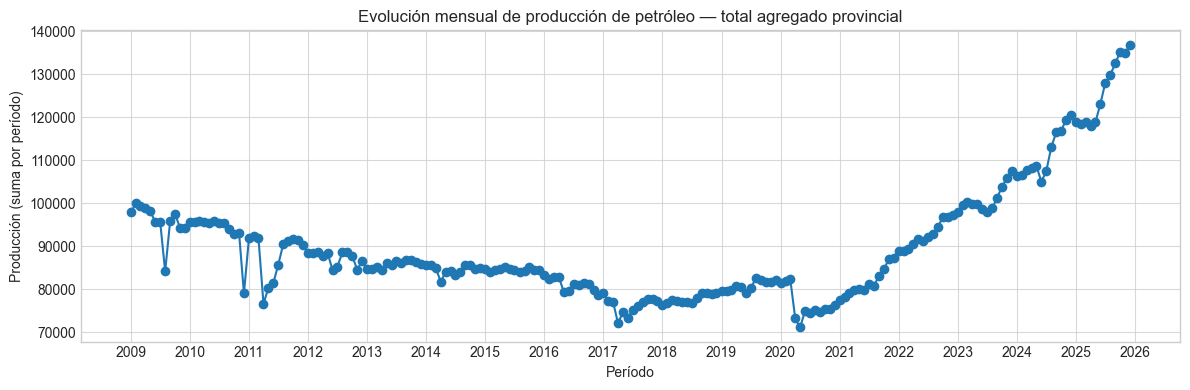

In [49]:
# Gráfica 1: evolución mensual de producción total agregada
ts_total = (
    df_model_clean_valid.groupby(["periodo_dt", "periodo_str"], as_index=False)["produccion"]
    .sum()
    .sort_values("periodo_dt")
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    ts_total["periodo_dt"],
    ts_total["produccion"],
    marker="o",
    linewidth=1.5,
)
ax.set_title(
    "Evolución mensual de producción de petróleo — total agregado provincial"
)
ax.set_xlabel("Período")
ax.set_ylabel("Producción (suma por período)")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.grid(True, alpha=0.75)
plt.tight_layout()
plt.show()


### Gráfica 2 — Ranking Top 15 (último período válido)

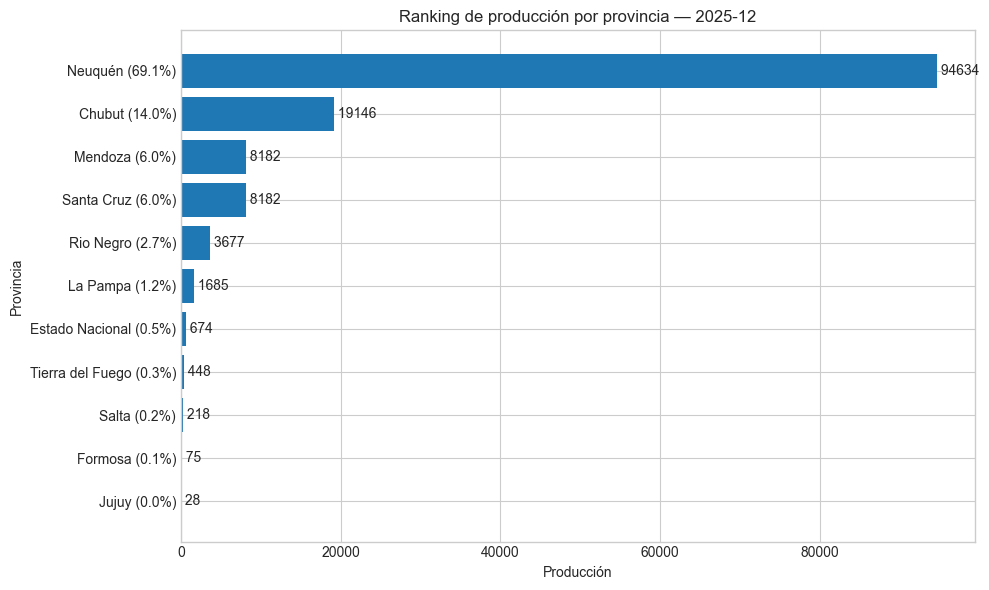

Período: 2025-12 | Total: 136948


,agrupador_nombre,produccion,participacion_pct
6,Neuquén,94633.56,69.10
0,Chubut,19146.44,13.98
5,Mendoza,8182.10,5.97
9,Santa Cruz,8181.51,5.97
7,Rio Negro,3677.40,2.69
4,La Pampa,1685.28,1.23
1,Estado Nacional,673.94,0.49
10,Tierra del Fuego,447.82,0.33
8,Salta,217.69,0.16
2,Formosa,74.86,0.05


In [43]:
# Gráfica 2: ranking Top 15 en el último período válido
df_periodo = df_model_clean_valid[
    df_model_clean_valid["periodo_str"] == latest_valid_period
].copy()

total_periodo = df_periodo["produccion"].sum()

ranking = (
    df_periodo.groupby("agrupador_nombre", as_index=False)["produccion"]
    .sum()
    .sort_values("produccion", ascending=False)
    .head(15)
)
ranking["participacion_pct"] = ranking["produccion"] / total_periodo * 100
ranking["label"] = ranking.apply(
    lambda r: f"{r['agrupador_nombre']} ({r['participacion_pct']:.1f}%)",
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ranking["label"], ranking["produccion"])
ax.invert_yaxis()
ax.set_title(
    f"Ranking de producción por {agrupador_tipo} — {latest_valid_period}"
)
ax.set_xlabel("Producción")
ax.set_ylabel(agrupador_tipo.capitalize())

for bar, value in zip(bars, ranking["produccion"]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {format_number(value, decimals=0)}",
        va="center",
    )

plt.tight_layout()
plt.show()

ranking_display = ranking[["agrupador_nombre", "produccion", "participacion_pct"]].round(2)
print(f"Período: {latest_valid_period} | Total: {format_number(total_periodo, 0)}")
display(ranking_display)


### Gráfica 3 — Top 5 agrupadores (últimos 12 períodos válidos)

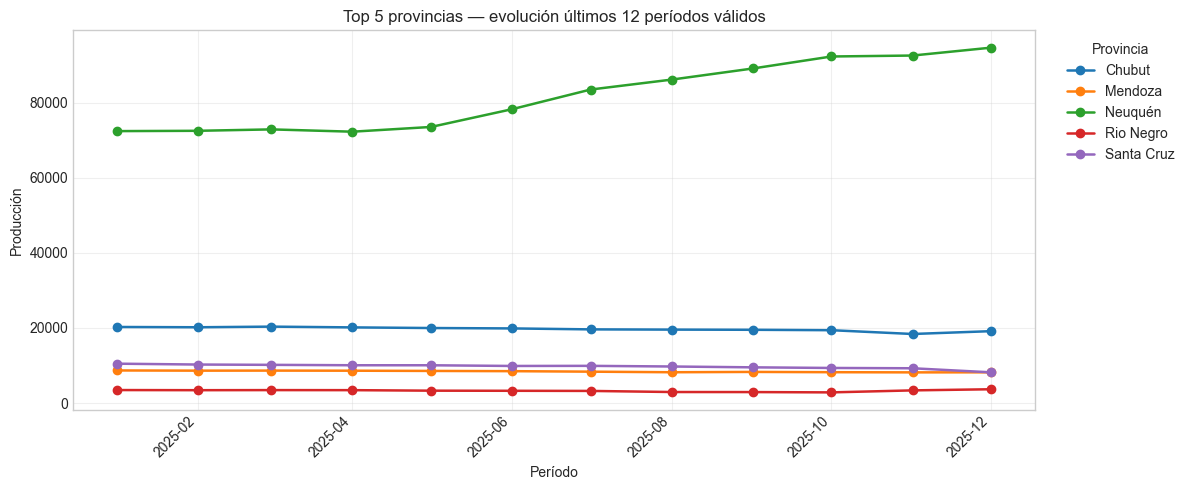

Períodos: 2025-01 → 2025-12
Top 5 según período: 2025-12


agrupador_nombre,Chubut,Mendoza,Neuquén,Rio Negro,Santa Cruz
periodo_str,,,,,
2025-01,20259.32,8683.48,72408.73,3463.50,10487.76
2025-02,20184.09,8627.95,72493.82,3427.18,10257.46
2025-03,20352.02,8643.13,72868.53,3451.00,10176.13
2025-04,20149.20,8616.61,72255.99,3436.65,10068.29
2025-05,19980.34,8554.68,73516.32,3299.36,10064.07
2025-06,19873.56,8493.45,78249.89,3266.98,9878.07
2025-07,19619.25,8360.69,83480.05,3232.23,9909.37
2025-08,19557.83,8205.94,86129.51,2940.18,9735.65
2025-09,19509.61,8292.53,89088.12,2925.97,9511.84


In [50]:
# Gráfica 3: Top 5 agrupadores — últimos 12 períodos válidos
recent_periods_str = (
    df_model_clean_valid[["periodo_dt", "periodo_str"]]
    .drop_duplicates()
    .sort_values("periodo_dt")["periodo_str"]
    .tail(12)
    .tolist()
)

top_groups = (
    df_model_clean_valid[df_model_clean_valid["periodo_str"] == latest_valid_period]
    .groupby("agrupador_nombre")["produccion"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

compare = df_model_clean_valid[
    df_model_clean_valid["periodo_str"].isin(recent_periods_str)
    & df_model_clean_valid["agrupador_nombre"].isin(top_groups)
]

pivot = (
    compare.pivot_table(
        index="periodo_str",
        columns="agrupador_nombre",
        values="produccion",
        aggfunc="sum",
    )
    .reindex(recent_periods_str)
)

pivot_dt = pd.to_datetime(pivot.index + "-01")

fig, ax = plt.subplots(figsize=(12, 5))
for col in pivot.columns:
    ax.plot(pivot_dt, pivot[col], marker="o", linewidth=1.8, label=col)

ax.set_title(
    f"Top 5 {agrupador_tipo}s — evolución últimos {len(recent_periods_str)} períodos válidos"
)
ax.set_xlabel("Período")
ax.set_ylabel("Producción")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.grid(True, alpha=0.3)
ax.legend(title=agrupador_tipo.capitalize(), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(f"Períodos: {recent_periods_str[0]} → {recent_periods_str[-1]}")
print(f"Top 5 según período: {latest_valid_period}")
display(pivot.round(2))


## 17. Exportación del dataset procesado

In [94]:
# Exportación del dataset procesado
EXPORT_COLUMNS = [
    "periodo_str",
    "periodo_dt",
    "anio",
    "mes",
    "producto",
    "agrupador_tipo",
    "agrupador_nombre",
    "tipo_recurso",
    "produccion",
    "source_resource",
]

export_df = df_model_clean_valid[EXPORT_COLUMNS].copy()
export_df["periodo_dt"] = export_df["periodo_dt"].dt.strftime("%Y-%m-%d")

clean_path = PROCESSED_DIR / f"{RESOURCE_KEY}_model_clean.csv"
export_df.to_csv(clean_path, encoding="utf-8-sig", index=False)
print(f"Dataset limpio: {clean_path}")

resumen = (
    df_model_clean_valid.groupby("periodo_str", as_index=False)
    .agg(
        produccion_total=("produccion", "sum"),
        cantidad_agrupadores=("agrupador_nombre", "nunique"),
    )
    .sort_values("periodo_str")
)

resumen_path = PROCESSED_DIR / f"{RESOURCE_KEY}_periodos_resumen.csv"
resumen.to_csv(resumen_path, encoding="utf-8-sig", index=False)
print(f"Resumen de períodos: {resumen_path}")
display(resumen.tail(10))


Dataset limpio: c:\Proyectos\Dashboards\OilAndGas\exploration\data\processed\petroleo_provincia_model_clean.csv
Resumen de períodos: c:\Proyectos\Dashboards\OilAndGas\exploration\data\processed\petroleo_provincia_periodos_resumen.csv


,periodo_str,produccion_total,cantidad_agrupadores
194,2025-03,119008.198092,11
195,2025-04,117987.121874,11
196,2025-05,118895.155427,11
197,2025-06,123233.615491,11
198,2025-07,128041.000048,11
199,2025-08,129936.355993,11
200,2025-09,132575.595076,11
201,2025-10,135275.043148,11
202,2025-11,134877.558310,11
203,2025-12,136948.474882,11


## 18. Conclusiones (completar tras ejecutar la notebook)

In [95]:
print("=" * 70)
print("CONCLUSIONES EXPLORATORIAS")
print("=" * 70)

print("\n1) Recursos útiles para el MVP")
for _, row in df_mvp.iterrows():
    flag = "✓" if row["found"] else "✗"
    print(f"   {flag} {row['mvp_target']}: {row['name']}")

print("\n2) Columnas reales del recurso descargado")
print(f"   {list(df_raw.columns)}")

print("\n3) Problemas de limpieza detectados")
issues = []
if df_raw.isna().any().any():
    issues.append(f"Valores nulos en: {df_raw.columns[df_raw.isna().any()].tolist()}")
if any(str(c).startswith("\ufeff") for c in df_raw.columns):
    issues.append("Posible BOM en encabezados (usar encoding='utf-8-sig')")
if not issues:
    issues.append("Sin problemas graves evidentes en esta muestra")
for item in issues:
    print(f"   - {item}")

print("\n4) Datos recomendados para primer dashboard Streamlit")
print("   - Producción promedio diaria por provincia/cuenca/empresa (CSV mensuales)")
print("   - Series SESCO + Tight/Shale por dimensión para comparar convencional vs no convencional")
print(f"   - Recurso analizado hoy: {source_resource_name}")

print("\n5) Dudas abiertas")
print("   - Unidades exactas y definiciones oficiales de cada columna de producción")
print("   - Solapamiento entre recursos 'promedio diaria' y 'SESCO + Tight y Shale'")
print("   - Frecuencia de actualización y lag de publicación")
print("   - Tratamiento de 'Estado Nacional' y categorías administrativas especiales")
print("   - Estrategia de unión temporal entre series anteriores a 2009 y posteriores")

CONCLUSIONES EXPLORATORIAS

1) Recursos útiles para el MVP
   ✓ petroleo_provincia: Producción de petróleo promedio diaria por provincia
   ✓ gas_provincia: Producción de gas promedio diaria por provincia
   ✓ petroleo_cuenca: Producción de petróleo promedio diaria por cuenca
   ✓ gas_cuenca: Producción de gas promedio diaria por cuenca
   ✓ petroleo_empresa: Producción de petróleo promedio diaria por empresa
   ✓ gas_empresa: Producción de gas promedio diaria por empresa

2) Columnas reales del recurso descargado
   ['anio', 'mes', 'indice_tiempo', 'provincia', 'produccion_petroleo_promedio_dia_m3']

3) Problemas de limpieza detectados
   - Sin problemas graves evidentes en esta muestra

4) Datos recomendados para primer dashboard Streamlit
   - Producción promedio diaria por provincia/cuenca/empresa (CSV mensuales)
   - Series SESCO + Tight/Shale por dimensión para comparar convencional vs no convencional
   - Recurso analizado hoy: Producción de petróleo promedio diaria por provinci